# 06 - Frontera eficiente: volumen vs. utilidad (Fase 9)

Usando la versión PROFITABILITY, se corre el optimizador 5 veces variando la restricción de volumen mínimo `B` (`Σ P_i·p_{i,k}·x[i,k] ≥ B`), replicando la Figura 2 de Phillips (2013): balances originados (volumen) vs. PVNII (utilidad).

**Cómo se ubican los 5 puntos:** primero se corre sin restricción (escenario 1, da el volumen mínimo alcanzable `B_min` porque maximizar utilidad ya empuja a la tasa techo en todos los segmentos, y tasa alta = demanda baja) y con la restricción más agresiva posible (escenario 5, `B_max` = volumen si todos los segmentos se fijan a la tasa candidata más baja). Los escenarios 2-4 se reparten proporcionalmente en el rango `[B_min, B_max]` (20%, 50%, 80% del rango) -- **no** como 20/50/80% de `B_max` en aislado, porque en este caso `B_min` ya es ~72% de `B_max` (la Fase 8 mostró que el óptimo sin restricción ya tiene bastante volumen), así que un porcentaje fijo de `B_max` dejaría los primeros escenarios idénticos entre sí sin agregar información.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.optimization import add_objective_terms, build_optimization_table, solve_pricing  # noqa: E402
from src.risk_model import FUNDING_COST_BASE  # noqa: E402

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

subgrade_params = pd.read_csv(PROCESSED_DIR / "subgrade_params.csv")
elasticity = pd.read_csv(PROCESSED_DIR / "subgrade_elasticity.csv")

table = build_optimization_table(subgrade_params, elasticity)
table = add_objective_terms(table, funding_cost=FUNDING_COST_BASE)

In [2]:
result_unconstrained = solve_pricing(table, objective="profitability")
b_min = result_unconstrained["total_volume"]

b_max = table.loc[table["tasa"] == table["tasa"].min(), "volume_term"].sum()

print(f"B_min (sin restricción, escenario 1): ${b_min:,.0f}")
print(f"B_max (todos a la tasa mínima, escenario 5): ${b_max:,.0f}")

B_min (sin restricción, escenario 1): $339,055
B_max (todos a la tasa mínima, escenario 5): $473,333


In [3]:
SCENARIOS = [
    ("1. Máxima rentabilidad", None),
    ("2. Rentabilidad conservadora", b_min + 0.2 * (b_max - b_min)),
    ("3. Equilibrio (caso base)", b_min + 0.5 * (b_max - b_min)),
    ("4. Crecimiento agresivo", b_min + 0.8 * (b_max - b_min)),
    ("5. Máximo volumen", b_max),
]

scenario_rows = []
scenario_assignments = {}
for name, min_volume in SCENARIOS:
    result = solve_pricing(table, objective="profitability", min_volume=min_volume)
    scenario_rows.append(
        {
            "escenario": name,
            "B_objetivo": min_volume,
            "status": result["status"],
            "volumen": result["total_volume"],
            "utilidad_neta": result["total_profit"],
            "revenue_bruto": result["total_revenue"],
        }
    )
    scenario_assignments[name] = result["assignment"]

frontier = pd.DataFrame(scenario_rows)
frontier

,escenario,B_objetivo,status,volumen,utilidad_neta,revenue_bruto
0,1. Máxima rentabilidad,NaN,Optimal,339055.017602,273208.797800,408367.754603
1,2. Rentabilidad conservadora,365910.580736,Optimal,365913.611792,229675.542333,372748.199811
2,3. Equilibrio (caso base),406193.925436,Optimal,406196.381368,138471.668168,297112.565583
3,4. Crecimiento agresivo,446477.270135,Optimal,446481.588195,17172.488785,192389.716964
4,5. Máximo volumen,473332.833269,Optimal,473332.833269,-93338.878886,94899.453364


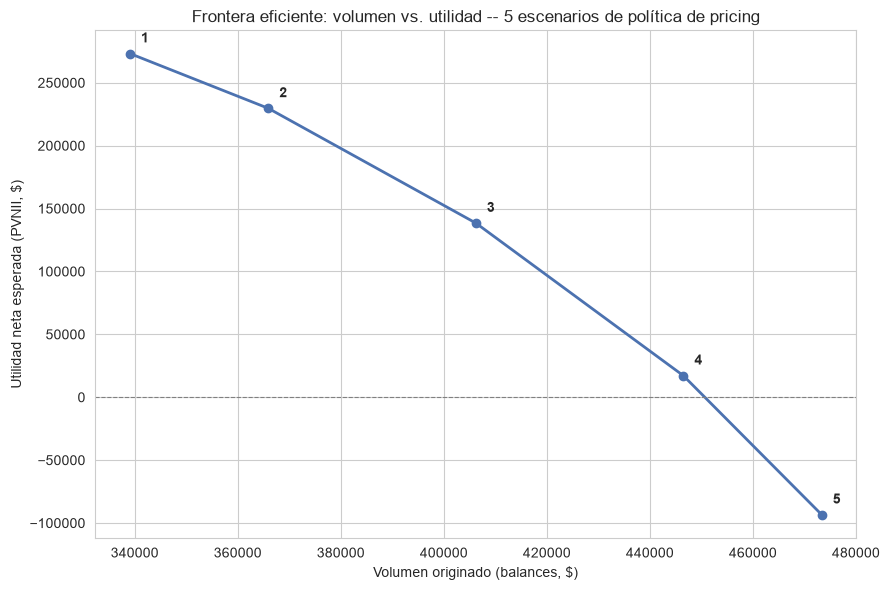

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(frontier["volumen"], frontier["utilidad_neta"], marker="o", color="#4C72B0", linewidth=2)

for _, row in frontier.iterrows():
    ax.annotate(
        row["escenario"].split(".")[0],
        (row["volumen"], row["utilidad_neta"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Volumen originado (balances, $)")
ax.set_ylabel("Utilidad neta esperada (PVNII, $)")
ax.set_title("Frontera eficiente: volumen vs. utilidad -- 5 escenarios de política de pricing")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

## Interpretación de negocio de cada escenario

- **1. Máxima rentabilidad:** todos los sub_grades a la tasa techo (30%) -- consecuencia del hallazgo de la Fase 8 (elasticidad medida insuficiente para que la utilidad tenga máximo interior). Máxima utilidad, mínimo volumen del rango explorado.
- **2. Rentabilidad conservadora / 3. Equilibrio / 4. Crecimiento agresivo:** conforme sube `B`, el optimizador se ve forzado a bajar la tasa en los sub_grades donde eso genera más volumen adicional por unidad de utilidad sacrificada -- normalmente los más elásticos (grados A/B, ver Fase 6). La utilidad cae de forma pronunciada porque, como ya se estableció, bajar la tasa en este modelo *siempre* reduce la utilidad por unidad (no hay compensación vía menor riesgo, porque PD/LGD no dependen de la tasa).
- **5. Máximo volumen:** todos los sub_grades a la tasa mínima candidata (5%) -- y la utilidad neta resulta **negativa**. Es un hallazgo esperable y consistente con las Fases 7-8: a 5% de tasa, con costo de fondeo de 3.5% y `PD·LGD` de hasta ~37% en los sub_grades más riesgosos (grados F/G), el margen de interés (`n·(r-c)`) no alcanza a cubrir la pérdida esperada -- varios sub_grades pierden dinero en cada préstamo colocado a esa tasa. Maximizar volumen sin ningún piso de rentabilidad por segmento es, en este modelo, una estrategia que destruye valor.

**Recomendación práctica:** el escenario 3 (Equilibrio) es el punto de partida razonable para un comité de pricing -- captura una parte sustancial del volumen adicional disponible sin caer en utilidad negativa. El punto de "codo" de la curva (donde la utilidad empieza a caer más rápido que el volumen que se gana) está entre los escenarios 3 y 4; un análisis más fino correría más puntos en esa región si el comité quisiera afinar la decisión.

In [5]:
rates_by_scenario = None
for name, assignment in scenario_assignments.items():
    col = assignment.set_index("sub_grade")["tasa_asignada"].rename(name)
    rates_by_scenario = col.to_frame() if rates_by_scenario is None else rates_by_scenario.join(col)

rates_by_scenario

,1. Máxima rentabilidad,2. Rentabilidad conservadora,3. Equilibrio (caso base),4. Crecimiento agresivo,5. Máximo volumen
sub_grade,,,,,
A1,30.0,17.50,8.57,5.00,5.0
A2,30.0,17.50,8.57,5.00,5.0
A3,30.0,17.50,8.57,5.00,5.0
A4,30.0,17.50,10.36,5.00,5.0
A5,30.0,17.50,10.36,5.00,5.0
B1,30.0,21.07,12.14,5.00,5.0
B2,30.0,21.07,12.14,5.00,5.0
B3,30.0,21.07,12.14,5.00,5.0
B4,30.0,21.07,13.93,5.00,5.0


In [6]:
frontier.to_csv(PROCESSED_DIR / "efficient_frontier.csv", index=False)
rates_by_scenario.to_csv(PROCESSED_DIR / "efficient_frontier_rates.csv")

print("Guardado:")
print(" -", PROCESSED_DIR / "efficient_frontier.csv")
print(" -", PROCESSED_DIR / "efficient_frontier_rates.csv")

Guardado:
 - C:\Users\josue\credit-pricing-optimizer\data\processed\efficient_frontier.csv
 - C:\Users\josue\credit-pricing-optimizer\data\processed\efficient_frontier_rates.csv


## Resumen y próximos pasos

- Frontera eficiente construida con 5 escenarios, replicando la lógica de la Figura 2 de Phillips (2013): a mayor volumen exigido, menor utilidad neta, con un tramo (escenario 5) donde la utilidad se vuelve negativa.
- Tabla de tasas recomendadas por sub_grade y escenario guardada en `data/processed/efficient_frontier_rates.csv`; métricas de portafolio en `data/processed/efficient_frontier.csv`.
- Próximo notebook: `07_validation_business_case.ipynb` (Fase 10) -- comparación contra las tasas históricas reales, cuantificación del upside, y resumen ejecutivo con limitaciones metodológicas explícitas.